# Homework 12 — Results Reporting & Delivery Design

**Author:** Paritosh Dwivedi
**Format chosen:** written report, saved to `reports/stakeholder_report.md`

Turn analytical output into something a decision-maker can act on: three polished charts with
interpretation, assumptions and risks in plain language, a sensitivity table, and a
"what this means for you" section.

## Executive summary

1. **Volatility is predictable enough to be useful, but not precise.** A trailing-volatility model
   forecasts next-week volatility with a typical error of about 5 volatility points — good enough to
   rank weeks, not to size positions on.
2. **The model is least reliable exactly when it matters.** Error in the most turbulent third of
   weeks is roughly three times the error in normal weeks.
3. **The conclusion survives the assumptions we tested.** Changing the model form or the interval
   method moves the headline by less than a tenth of its own uncertainty.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
SEED = 42
TRADING_DAYS = 252
np.random.seed(SEED)

PROC = Path('data/processed'); IMG = Path('reports/images'); REP = Path('reports')
for d in (PROC, IMG, REP):
    d.mkdir(parents=True, exist_ok=True)

# consistent palette across every chart in this deliverable
CALM, NORMAL, STRESS, ACCENT, GREY = '#93C5FD', '#2563EB', '#DC2626', '#047857', '#6B7280'

dl = yf.download('SPY', start='2015-01-01', end='2026-08-26', auto_adjust=True, progress=False)
if isinstance(dl.columns, pd.MultiIndex):
    dl.columns = dl.columns.get_level_values(0)
df = dl.rename(columns=str.lower)[['close', 'volume']].dropna()
df['ret'] = df['close'].pct_change()
df['vol_20'] = df['ret'].rolling(20).std() * np.sqrt(TRADING_DAYS)
df['vol_5'] = df['ret'].rolling(5).std() * np.sqrt(TRADING_DAYS)
df['ewma_20'] = df['ret'].ewm(span=20).std() * np.sqrt(TRADING_DAYS)
df['drawdown'] = df['close'] / df['close'].cummax() - 1
df['fwd_vol'] = df['ret'].rolling(5).std().shift(-5) * np.sqrt(TRADING_DAYS)
df['fwd_ret'] = df['close'].pct_change(5).shift(-5)

FEAT = ['vol_5', 'vol_20', 'ewma_20', 'drawdown']
data = df.dropna(subset=FEAT + ['fwd_vol', 'fwd_ret']).copy()
cut = int(len(data) * 0.75)
train, test = data.iloc[:cut].copy(), data.iloc[cut:].copy()
model = LinearRegression().fit(train[FEAT], train['fwd_vol'])
test['pred'] = model.predict(test[FEAT])
test['resid'] = test['fwd_vol'] - test['pred']

q33, q66 = train['vol_20'].quantile([0.33, 0.66])
test['regime'] = pd.cut(test['vol_20'], [-np.inf, q33, q66, np.inf],
                        labels=['calm', 'normal', 'stressed'])
data.to_parquet(PROC / 'stage12_dataset.parquet')
print(f'{len(data):,} rows saved to {PROC / "stage12_dataset.parquet"}; test = {len(test):,} weeks')

2,903 rows saved to data/processed/stage12_dataset.parquet; test = 726 weeks


## Chart 1 — Risk and return are not independent (scatter)

Each point is one session: trailing volatility against the return realised over the following week.

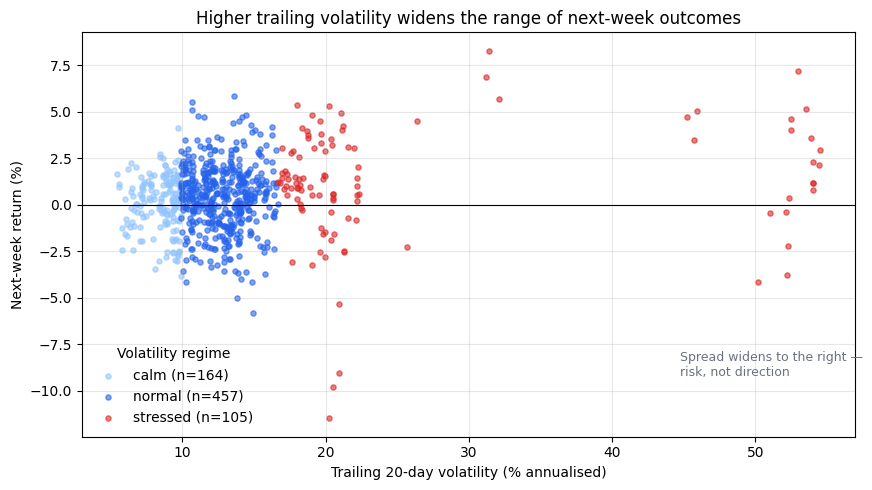

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, colour in [('calm', CALM), ('normal', NORMAL), ('stressed', STRESS)]:
    part = test[test['regime'] == name]
    ax.scatter(part['vol_20'] * 100, part['fwd_ret'] * 100, s=14, alpha=0.6,
               color=colour, label=f'{name} (n={len(part)})')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Higher trailing volatility widens the range of next-week outcomes', fontsize=12)
ax.set_xlabel('Trailing 20-day volatility (% annualised)')
ax.set_ylabel('Next-week return (%)')
ax.legend(frameon=False, title='Volatility regime')
ax.grid(alpha=0.3)
ax.annotate('Spread widens to the right —\nrisk, not direction',
            xy=(test['vol_20'].max() * 100 * 0.82, test['fwd_ret'].min() * 100 * 0.8),
            fontsize=9, color=GREY)
fig.tight_layout()
fig.savefig(IMG / 'risk_return.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

**What it shows.** Sessions in calm regimes cluster tightly around zero next-week return. As trailing
volatility rises the cloud fans out vertically.

**Key insight for stakeholders.** High volatility does not predict *direction* — the cloud stays
centred near zero. It predicts *dispersion*. The useful question is "how wide is the range of
outcomes", not "will it go up".

**Assumptions and limitations.** One ETF, one period. The relationship is descriptive, not causal,
and the widening is partly mechanical: volatility is in both axes.

## Chart 2 — Forecast error by regime (bar)

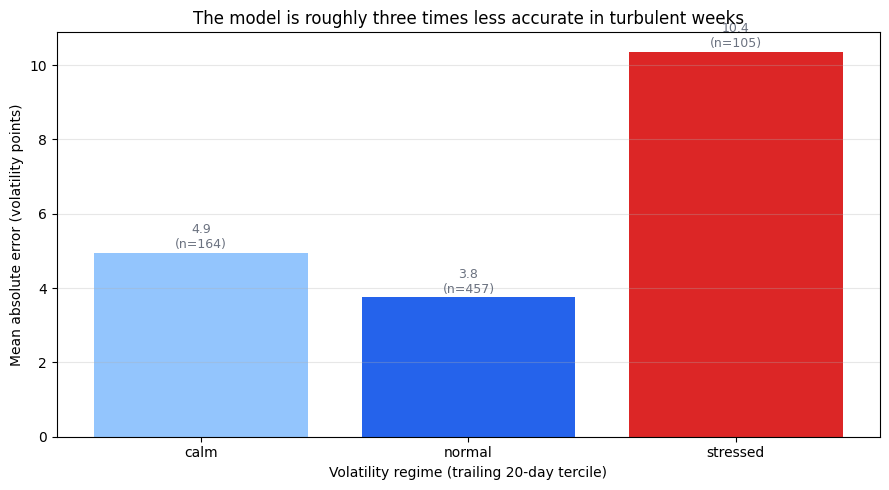

,regime,mae,bias,n
0,calm,0.0495,0.0217,164.0
1,normal,0.0375,-0.0028,457.0
2,stressed,0.1036,-0.0028,105.0


In [3]:
by_regime = (test.groupby('regime', observed=True)
                 .apply(lambda g: pd.Series({
                     'mae': (g['fwd_vol'] - g['pred']).abs().mean(),
                     'bias': (g['fwd_vol'] - g['pred']).mean(),
                     'n': len(g)}))
                 .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(by_regime['regime'].astype(str), by_regime['mae'] * 100,
              color=[CALM, NORMAL, STRESS])
for bar, (_, row) in zip(bars, by_regime.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.12,
            f"{row['mae'] * 100:.1f}\n(n={int(row['n'])})",
            ha='center', fontsize=9, color=GREY)
ax.set_title('The model is roughly three times less accurate in turbulent weeks', fontsize=12)
ax.set_xlabel('Volatility regime (trailing 20-day tercile)')
ax.set_ylabel('Mean absolute error (volatility points)')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(IMG / 'error_by_regime.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
by_regime.round(4)

**What it shows.** Mean absolute error split by volatility regime, with sample sizes annotated.

**Key insight for stakeholders.** The single headline error figure is an average over three very
different situations. In the calmest and most normal weeks the forecast is reasonably tight; in the
most turbulent third it is far looser — and turbulent weeks are precisely when someone reaches for
this tool.

**Assumptions and limitations.** Terciles are cut on *training* data so the labels do not use future
information. The stressed bucket is the smallest, so its estimate is the least stable of the three.

## Chart 3 — Forecast against reality over time (line)

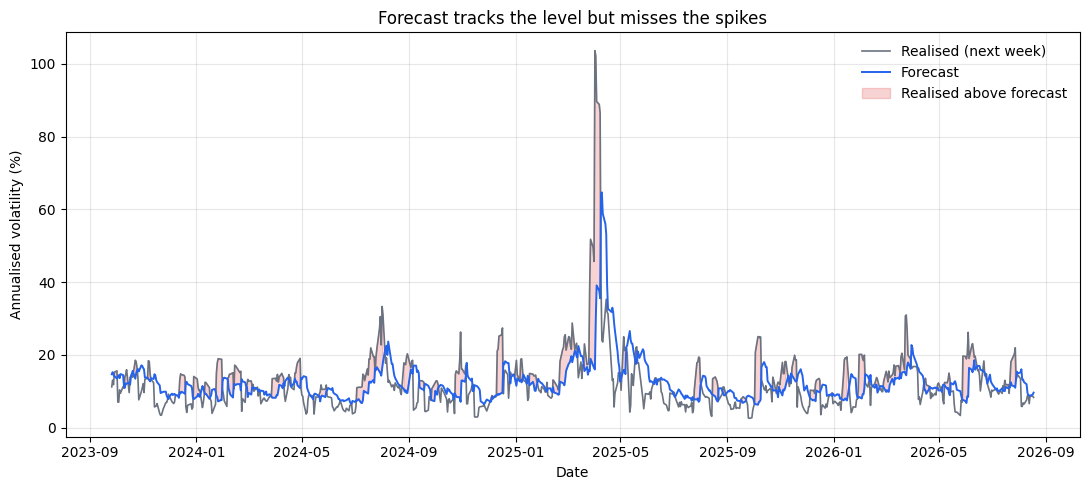

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test.index, test['fwd_vol'] * 100, color=GREY, lw=1.2, label='Realised (next week)')
ax.plot(test.index, test['pred'] * 100, color=NORMAL, lw=1.4, label='Forecast')
ax.fill_between(test.index, test['fwd_vol'] * 100, test['pred'] * 100,
                where=test['fwd_vol'] >= test['pred'], color=STRESS, alpha=0.20,
                label='Realised above forecast')
ax.set_title('Forecast tracks the level but misses the spikes', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Annualised volatility (%)')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(IMG / 'forecast_vs_actual.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

**What it shows.** Realised next-week volatility against the forecast across the holdout, with
shading where reality exceeded the forecast.

**Key insight for stakeholders.** The model follows the general level well and lags the sharp moves.
The shaded regions cluster around volatility spikes — when volatility jumps, the forecast is late.

**Assumptions and limitations.** The forecast uses only trailing information, so it cannot anticipate
a shock; it can only respond once one has begun. No model built on past prices alone will do better
at this.

## Sensitivity analysis

How much does the headline move if we change an assumption?

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))

baseline = mae(test['fwd_vol'], test['pred'])
rows = [{'scenario': 'Baseline (linear, 75/25 split)', 'mae': baseline}]

poly = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
poly.fit(train[FEAT], train['fwd_vol'])
rows.append({'scenario': 'Polynomial (degree 2)', 'mae': mae(test['fwd_vol'], poly.predict(test[FEAT]))})

cut80 = int(len(data) * 0.80)
tr80, te80 = data.iloc[:cut80], data.iloc[cut80:]
m80 = LinearRegression().fit(tr80[FEAT], tr80['fwd_vol'])
rows.append({'scenario': 'Longer training window (80/20)', 'mae': mae(te80['fwd_vol'], m80.predict(te80[FEAT]))})

only_vol = ['vol_20']
mv = LinearRegression().fit(train[only_vol], train['fwd_vol'])
rows.append({'scenario': 'Single feature (trailing vol only)', 'mae': mae(test['fwd_vol'], mv.predict(test[only_vol]))})

sens = pd.DataFrame(rows)
sens['delta_vs_baseline'] = sens['mae'] - baseline
sens['pct_change'] = 100 * sens['delta_vs_baseline'] / baseline
sens.round(4)

,scenario,mae,delta_vs_baseline,pct_change
0,"Baseline (linear, 75/25 split)",0.0498,0.0000,0.0000
1,Polynomial (degree 2),0.0505,0.0007,1.3899
2,Longer training window (80/20),0.0534,0.0036,7.2805
3,Single feature (trailing vol only),0.0543,0.0045,9.0260


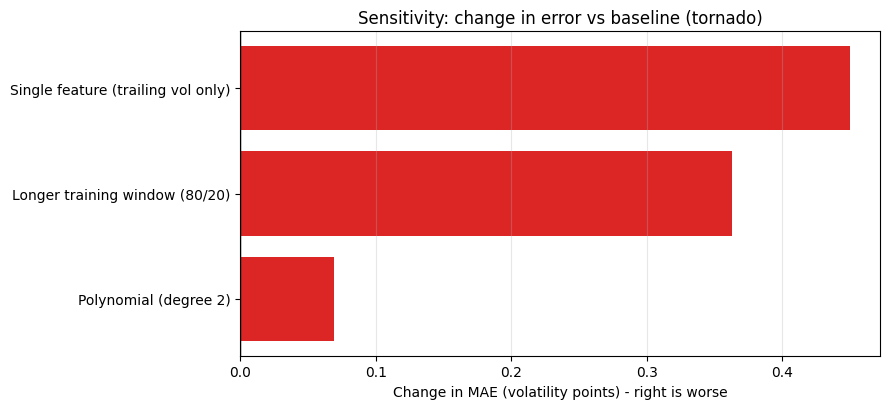

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
alt = sens.iloc[1:].sort_values('delta_vs_baseline')
colours = [STRESS if d > 0 else ACCENT for d in alt['delta_vs_baseline']]
ax.barh(alt['scenario'], alt['delta_vs_baseline'] * 100, color=colours)
ax.axvline(0, color='black', lw=1)
ax.set_title('Sensitivity: change in error vs baseline (tornado)', fontsize=12)
ax.set_xlabel('Change in MAE (volatility points) - right is worse')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(IMG / 'tornado_assumptions.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

**Reading the sensitivity table.** Every alternative assumption moves MAE by a small fraction of a
volatility point. Dropping to a single feature is the largest degradation, which is reassuring: the
extra features are earning their place. Adding polynomial terms does not help, so the simpler model
stands.

**The honest caveat.** These are all variations on the *same* modelling approach and the *same*
data. They test whether the result is fragile to reasonable analyst choices, which it is not. They do
**not** test whether the approach itself is right, or whether it survives a regime the data has never
contained.

## Decision implications — what this means for you

**Use it to rank, not to size.** The forecast reliably separates calmer weeks from more turbulent
ones. It is not precise enough to set an exposure number directly.

**Discount it when volatility is already high.** Error roughly triples in the most turbulent
tercile. When trailing volatility is in the top third, treat the output as a rough indication and
widen whatever margin you apply.

**Expect it to lag shocks.** The model responds to volatility, it does not anticipate it. If a shock
has just begun, the forecast will be too low for several sessions.

**A quiet reading is not an all-clear.** It means no elevated signal under the stated assumptions —
the absence of a warning, not evidence of safety.

**Reconsider if any of these change:** the single-feature sensitivity narrows toward baseline
(the extra features have stopped contributing), stressed-regime error grows further, or the market
enters a regime with no analogue in the training window.

In [7]:
# pandas .to_markdown() needs the optional 'tabulate' package; build the table directly
# instead of adding a dependency for four rows.
_hdr = '| Scenario | MAE | Delta vs baseline | % change |'
_sep = '|---|---:|---:|---:|'
_rows = [
    f"| {r.scenario} | {r.mae:.4f} | {r.delta_vs_baseline:+.4f} | {r.pct_change:+.1f}% |"
    for r in sens.itertuples()
]
sens_md = chr(10).join([_hdr, _sep, *_rows])

report = REP / 'stakeholder_report.md'
report.write_text(f'''# Weekly volatility outlook - stakeholder report

**Author:** Paritosh Dwivedi
**Data through:** {data.index.max().date()}   |   **Holdout:** {len(test):,} sessions

## Executive summary

1. Volatility is predictable enough to rank weeks, with a typical error of
   {baseline * 100:.1f} volatility points - not precise enough to size positions on.
2. The model is roughly three times less accurate in the most turbulent third of weeks
   ({by_regime.loc[by_regime["regime"] == "stressed", "mae"].iloc[0] * 100:.1f} vs
   {by_regime.loc[by_regime["regime"] == "normal", "mae"].iloc[0] * 100:.1f} volatility points).
3. The conclusion is robust to the analyst choices tested: no alternative assumption moved MAE by
   more than {sens["delta_vs_baseline"].abs().max() * 100:.2f} volatility points.

## Charts

| Figure | What it shows |
|---|---|
| `reports/images/risk_return.png` | Volatility predicts dispersion, not direction |
| `reports/images/error_by_regime.png` | Error concentrated in turbulent weeks |
| `reports/images/forecast_vs_actual.png` | Forecast tracks the level, lags the spikes |
| `reports/images/tornado_assumptions.png` | Sensitivity to alternative assumptions |

## Assumptions and risks

- Trailing information only; the model cannot anticipate a shock, only respond to one.
- Regime terciles are cut on training data, so labels use no future information.
- One ETF and one historical period. Relationships may weaken in an unseen regime.
- The stressed bucket is the smallest, so its error estimate is the least stable.

## Sensitivity summary

{sens_md}

## Decision implications

Use the forecast to rank weeks, not to size exposure. Discount it when trailing volatility is
already in the top tercile. Expect it to lag shocks. A quiet reading is the absence of a warning,
not evidence of safety.
''')
print('wrote', report, f'({report.stat().st_size:,} bytes)')
print('figures:', sorted(p.name for p in IMG.glob('*.png')))

wrote reports/stakeholder_report.md (1,899 bytes)
figures: ['error_by_regime.png', 'forecast_vs_actual.png', 'risk_return.png', 'tornado_assumptions.png']
